In [1]:
import cobra

In [ ]:
model = cobra.io.read_sbml_model("../../../model.xml")

In [4]:
# Define the ED reaction ID
ed_rxn = model.reactions.rxn01477_c0
# Define the biomass reaction ID
biomass_rxn = "bio1_biomass"
# Define a reaction to indicate flux through the EMP
emp_rxn = model.reactions.rxn00558_c0

In [3]:
# Define a medium
medium = {
    "EX_cpd00027_e0": 10,  # Glucose
    "EX_cpd00007_e0": 20,  # Oxygen
    "EX_cpd00013_e0": 1000,  # Ammonia
    "EX_cpd00011_e0": 1000,  # CO2
    "EX_cpd00067_e0": 1000,  # H+
    "EX_cpd00009_e0": 1000,  # Phosphate
    "EX_cpd00001_e0": 1000,  # H2O
    "EX_cpd00063_e0": 1000,  # Ca2+
    "EX_cpd00099_e0": 1000,  # Cl-
    "EX_cpd00149_e0": 1000,  # Co2+
    "EX_cpd00058_e0": 1000,  # Cu2+
    "EX_cpd00254_e0": 1000,  # Mg2+
    "EX_cpd00205_e0": 1000,  # K+
    "EX_cpd00971_e0": 1000,  # Na+
    "EX_cpd00048_e0": 1000,  # Sulfate
    "EX_cpd00034_e0": 1000,  # Zn2+
    "EX_cpd10516_e0": 1000,  # Fe+3
    "EX_cpd00030_e0": 1000,  # Mn2+_e0
}
model.medium = medium

In [6]:
# Make a dictionary to hold the constraint as the key and the solution as the value
results = {}

# Loop through a range of values for the total flux constraint
for total_flux in range(0, 2000, 100):
    # Make a copy of the model
    working_model = model.copy()

    # Add a constraint on the sum of the absolute values of every flux in the
    # network to be less than total_flux
    coefficients = dict()
    for rxn in model.reactions:
        coefficients[rxn.forward_variable] = 1.0
        coefficients[rxn.reverse_variable] = 1.0
    constraint = model.problem.Constraint(0, lb=0, ub=total_flux)
    working_model.add_cons_vars(constraint)
    working_model.solver.update()
    constraint.set_linear_coefficients(coefficients=coefficients)

    # Run pFBA
    sol = working_model.optimize()

    # Make a dictionary with the full solution and some key fluxes
    sol_dict = {
        "solution": sol,
        "status": sol.status,
        "growth_rate": sol.fluxes[biomass_rxn],
        "ed_flux": sol.fluxes[ed_rxn.id],
        "emp_flux": sol.fluxes[emp_rxn.id],
    }

    # Add the results to the list
    results[total_flux] = sol_dict

/Users/helenscott/Documents/PhD/Segre-lab/GEM-repos/GEM-mit1002/.venv/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


In [7]:
results

{0: {'solution': <Solution infeasible at 0x1197a38d0>,
  'status': 'infeasible',
  'growth_rate': np.float64(0.0),
  'ed_flux': np.float64(0.0),
  'emp_flux': np.float64(0.0)},
 100: {'solution': <Solution 0.048 at 0x11a107d50>,
  'status': 'optimal',
  'growth_rate': np.float64(0.04829669910036992),
  'ed_flux': np.float64(0.0),
  'emp_flux': np.float64(1.3324470043059171)},
 200: {'solution': <Solution 0.157 at 0x11a5f6950>,
  'status': 'optimal',
  'growth_rate': np.float64(0.15698981495842995),
  'ed_flux': np.float64(0.0),
  'emp_flux': np.float64(2.7872946531917178)},
 300: {'solution': <Solution 0.266 at 0x11af4f050>,
  'status': 'optimal',
  'growth_rate': np.float64(0.2656829308164907),
  'ed_flux': np.float64(0.0),
  'emp_flux': np.float64(4.242142302077505)},
 400: {'solution': <Solution 0.374 at 0x11919f250>,
  'status': 'optimal',
  'growth_rate': np.float64(0.3743760466745511),
  'ed_flux': np.float64(0.0),
  'emp_flux': np.float64(5.696989950963295)},
 500: {'solution': 

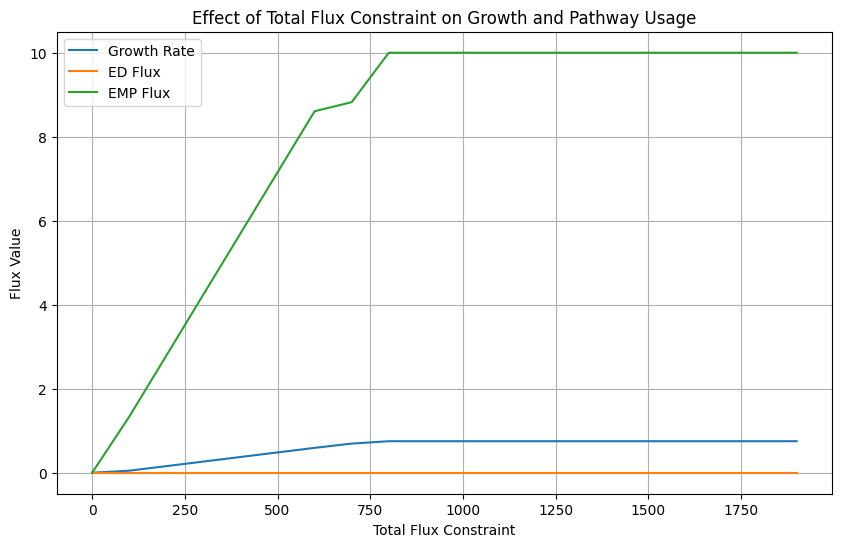

In [8]:
# Plot the growth rate, ED flux, and EMP flux as a function of the total flux constraint
import matplotlib.pyplot as plt
total_fluxes = list(results.keys())
growth_rates = [results[tf]["growth_rate"] for tf in total_fluxes]
ed_fluxes = [results[tf]["ed_flux"] for tf in total_fluxes]
emp_fluxes = [results[tf]["emp_flux"] for tf in total_fluxes]
plt.figure(figsize=(10, 6))
plt.plot(total_fluxes, growth_rates, label="Growth Rate")
plt.plot(total_fluxes, ed_fluxes, label="ED Flux")
plt.plot(total_fluxes, emp_fluxes, label="EMP Flux")
plt.xlabel("Total Flux Constraint")
plt.ylabel("Flux Value")
plt.title("Effect of Total Flux Constraint on Growth and Pathway Usage")
plt.legend()
plt.grid()
plt.show()

In [9]:
# Save the fluxes to JSON files
for total_flux, sol_dict in results.items():
    sol_dict["solution"].fluxes.to_json(f"fluxes_total_flux_{total_flux}.json")